In [1]:
from torch.optim import SGD, Adam
from torch.optim.lr_scheduler import MultiStepLR
import torch.nn.functional as F
from torch import nn
import torch
import os
import torchvision.transforms as transforms
import math
import pickle
import pandas as pd
import numpy as np 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
data_1 = pd.read_excel('C:/Users/ET_DY/Desktop/paper/MINE/NNGP-DCM/data/swssmetro_all.xlsx')

import torch 
print(torch.cuda.is_available())
print(torch.backends.cudnn.version())
print("CUDA version:", torch.version.cuda)
if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.get_device_name(torch.cuda.current_device()))

import pandas as pd

# 设置随机种子以确保结果的可复现性
random_state = 42
test_data = data_1.sample(frac=0.3, random_state=random_state)
# 剩余的数据即为训练集
train_data = data_1.drop(test_data.index)
# 打印结果，确保数据被正确划分
print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

x_train=train_data.iloc[:,18:27].values
z_train=train_data.iloc[:,28:53].values
label_train=train_data.iloc[:,53:56].values
x_test=test_data.iloc[:,18:27].values
z_test=test_data.iloc[:,28:53].values
label_test=test_data.iloc[:,53:56].values
x_train=torch.tensor(x_train, dtype=torch.float)
z_train=torch.tensor(z_train, dtype=torch.float)
label_train=torch.tensor(label_train, dtype=torch.float)
x_test=torch.tensor(x_test, dtype=torch.float)
z_test=torch.tensor(z_test, dtype=torch.float)
label_test=torch.tensor(label_test, dtype=torch.float)
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, x_data, z_data, labels):
        self.x_data = x_data
        self.z_data = z_data
        self.labels = labels

    def __getitem__(self, index):
        return self.x_data[index], self.z_data[index], self.labels[index]

    def __len__(self):
        return len(self.x_data)
    
from torch.utils.data import DataLoader
# 假设 x_data, z_data, labels 是你的训练数据和标签
dataset_train = CustomDataset(x_train, z_train, label_train)
data_loader1 = DataLoader(dataset_train, batch_size=len(label_train), shuffle=True)
#data_loader1 = DataLoader(dataset_train, batch_size=512, shuffle=True)
dataset_test = CustomDataset(x_test, z_test, label_test)
#data_loader2 = DataLoader(dataset_test, batch_size=512, shuffle=True)
data_loader2 = DataLoader(dataset_test, len(label_test), shuffle=True)

True
8700
CUDA version: 11.8
Current CUDA device: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Training set size: 7484
Test set size: 3208


In [2]:
import os
print(os.getcwd())  # 显示当前工作目录
print(os.path.abspath("你的文件名.ipynb"))  # 显示文件绝对路径

C:\Users\ET_DY
C:\Users\ET_DY\你的文件名.ipynb


In [2]:
from torch.autograd import grad
def cal_loss(model, x, z, y, GR, base, lambd, criterion):
    '''
    仅对ChoiceModel中的PN1施加梯度约束
    
    参数:
    - model: ChoiceModel实例
    - x: 模型输入x（用于FeatureProduce生成x1/x2/x3）
    - z: 模型输入z（用于WeightNN）
    - y: 标签
    - GR: 梯度正则类型（'UGR'/'PGR'/'LGR'/'none'）
    - base: 正则项计算方式（'sum'或其他，对应正梯度和或平方和）
    - lambd: 正则项权重
    - criterion: 基础损失函数（如交叉熵）
    '''
    # 1. 计算基础损失（基于模型最终输出）
    
    choice_probabilities = model(x, z)  # 模型输出：选择概率
    log_probs = torch.log(choice_probabilities)  # NLLLoss需要对数概率
    loss = criterion(log_probs, y)
    
    # 若无需梯度约束，直接返回基础损失
    if GR == None :
        return loss
    
    # 2. 提取PN1的输入和输出（用于计算梯度）
    # 2.1 生成中间特征x1/x2/x3（与ChoiceModel.forward逻辑一致）
    x1, x2, x3 = model.feature_produce(x)
    # 处理可能的NaN（与模型内部保持一致）
    x1[torch.isnan(x1)] = 0
    x2[torch.isnan(x2)] = 0
    x3[torch.isnan(x3)] = 0
    #print(f'execute grad constrain')
    # 2.2 记录每个PN1的输出（共12个）
    pn1_outputs = []
    # PN1[0-3]对应x1的0-3列
    for i in range(4):
        pn1_out = model.PN1[i](x1[:, i])  # x1[:,i]是PN1[i]的输入
        pn1_outputs.append(pn1_out)
    # PN1[4-8]对应x2的0-4列
    for i in range(5):
        pn1_out = model.PN1[4+i](x2[:, i])  # x2[:,i]是PN1[4+i]的输入
        pn1_outputs.append(pn1_out)
    # PN1[9-11]对应x3的0-2列
    for i in range(3):
        pn1_out = model.PN1[9+i](x3[:, i])  # x3[:,i]是PN1[9+i]的输入
        pn1_outputs.append(pn1_out)
    
    # 3. 根据GR类型计算梯度正则项
    # 3.1 定义需要关注的输入特征（这里直接使用PN1的直接输入x1/x2/x3的对应列）
    pn1_inputs = []
    pn1_inputs.extend([x1[:, i] for i in range(4)])  # PN1[0-3]的输入
    pn1_inputs.extend([x2[:, i] for i in range(5)])  # PN1[4-8]的输入
    pn1_inputs.extend([x3[:, i] for i in range(3)])  # PN1[9-11]的输入
    
    # 3.2 计算每个PN1输出对其输入的梯度
    grads = []
    for idx in range(12):  # 遍历12个PN1
        out = pn1_outputs[idx]  # 第idx个PN1的输出
        inp = pn1_inputs[idx]   # 第idx个PN1的输入（x1/x2/x3的某一列）
        # 计算梯度（create_graph=True确保二阶导数可求，用于后续反向传播）
        g = grad(
            out, inp, 
            grad_outputs=torch.ones_like(out),  # 梯度权重为1
            create_graph=True, 
            retain_graph=True,
            allow_unused=True  # 允许未使用的输入，避免报错
        )[0]  # 返回梯度张量（形状与inp一致）
        if g is None:
            # 生成与输入形状相同的零张量，且在同一设备上
            g = torch.zeros_like(inp, device=inp.device)
        grads.append(g)  # 此时grads中全是张量，无None

    for idx, (out, inp) in enumerate(zip(pn1_outputs, pn1_inputs)):
        # 检查输入是否在计算图中被使用
        if not inp.grad_fn:
            print(f"警告：PN1[{idx}]的输入特征未参与计算（可能是代码逻辑错误）")
            
    # 4. 聚合梯度并计算正则项（根据base选择计算方式）
    if base == 'sum':
        # 仅累加正梯度（例如约束PN1输出随输入增大而单调递增）
        reg = sum(g[g <= 0].sum() for g in grads)
    else:
        # L2正则（惩罚过大梯度，保证平滑性）
        reg = sum(torch.pow(g, 2).sum() for g in grads)
    
    # 5. 总损失 = 基础损失 + PN1的梯度正则项
    return loss + lambd * reg

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import torch.nn.functional as F

# 定义网络架构
class PN1(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, final_hidden_size=64, output_size=1):
        super(PN1, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.softplus1 = nn.Softplus()  # 替换原有的ReLU
        
        self.fc2 = nn.Linear(hidden_size, final_hidden_size)
        self.softplus2 = nn.Softplus()  # 替换原有的Sigmoid
        
        self.fc3 = nn.Linear(final_hidden_size, output_size)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # 扩展维度：[batch_size] → [batch_size, 1]
        out = self.fc1(x)
        out = self.softplus1(out)  # 使用Softplus激活
        
        out = self.fc2(out)
        out = self.softplus2(out)  # 第二层也使用Softplus
        
        out = self.fc3(out)
        return out
        
class WeightNN(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size0=5, output_size1=6, output_size2=4):
        super(WeightNN, self).__init__()
        self.hidden1 = nn.Linear(input_size, hidden_size1)
        self.hidden2_para1 = nn.Linear(hidden_size1, hidden_size2)
        self.hidden2_para2 = nn.Linear(hidden_size1, hidden_size2)
        self.hidden2_para3 = nn.Linear(hidden_size1, hidden_size2)
        self.output0 = nn.Linear(hidden_size2, output_size0)
        self.output1 = nn.Linear(hidden_size2, output_size1)
        self.output2 = nn.Linear(hidden_size2, output_size2)
        self.output3 = nn.Linear(hidden_size1, 3)

    def forward(self, z):
        N = len(z)
        f2 = torch.zeros(N, 12, device=z.device)
        f4 = torch.zeros(N, 3, device=z.device)
        f = F.leaky_relu(self.hidden1(z))
        f1_0 = F.leaky_relu(self.hidden2_para1(f))
        f2_0 = torch.sigmoid(self.output0(f1_0))
        f1_1 = F.leaky_relu(self.hidden2_para2(f))
        f2_1 = torch.sigmoid(self.output1(f1_1))
        f1_2 = F.leaky_relu(self.hidden2_para3(f))
        f2_2 = torch.sigmoid(self.output2(f1_2))
        f3 = self.output3(f)

        f2[:, 0] = -f2_0[:, 0]
        f2[:, 1] = -f2_0[:, 1]
        f2[:, 2] = f2_0[:, 2]
        f2[:, 3] = f2_0[:, 3]
        f2[:, 4] = -f2_1[:, 0]
        f2[:, 5] = -f2_1[:, 1]
        f2[:, 6] = f2_1[:, 2]
        f2[:, 7] = f2_1[:, 3]
        f2[:, 8] = f2_1[:, 4]
        f2[:, 9] = -f2_2[:, 0]
        f2[:, 10] = -f2_2[:, 1]
        f2[:, 11] = f2_2[:, 2]
        
        f4[:,0] = f2_0[:, 4]
        f4[:,1] = f2_1[:, 5]
        f4[:,2] = f2_2[:, 3]
        
        

        return f2, f4, f3

class FeatureProduce(nn.Module):
    def __init__(self):
        super(FeatureProduce, self).__init__()

    def forward(self, x):
        # 直接从x构造x1/x2/x3，避免用torch.zeros（防止梯度断裂）
        # x1: 前3列 + 第1列/第0列（形状：[N,4]）
        x1 = torch.cat([
            x[:, 0:3],  # 前3列（直接来自x，保留梯度）
            (x[:, 1] / x[:, 0]).unsqueeze(1)  # 第3列（除法操作，保留梯度）
        ], dim=1)
        
        # x2: 第3-6列 + 第4列/第3列（形状：[N,5]）
        x2 = torch.cat([
            x[:, 3:7],  # 第3-6列
            (x[:, 4] / x[:, 3]).unsqueeze(1)  # 第4列
        ], dim=1)
        
        # x3: 第7-8列 + 第8列/第7列（形状：[N,3]）
        x3 = torch.cat([
            x[:, 7:9],  # 第7-8列
            (x[:, 8] / x[:, 7]).unsqueeze(1)  # 第2列
        ], dim=1)
        
        # 处理NaN（用0填充，但保留梯度）
        x1 = torch.where(torch.isnan(x1), torch.zeros_like(x1), x1)
        x2 = torch.where(torch.isnan(x2), torch.zeros_like(x2), x2)
        x3 = torch.where(torch.isnan(x3), torch.zeros_like(x3), x3)
        
        return x1, x2, x3
    
class ChoiceModel(nn.Module):
    def __init__(self):
        super(ChoiceModel, self).__init__()
        self.WeightNN = WeightNN(input_size=25, hidden_size1=100, hidden_size2=100, output_size0=5, output_size1=6, output_size2=4)
        self.PN1 = nn.ModuleList([PN1() for _ in range(12)])
        #self.PN2 = nn.ModuleList([PN2(input_size=4), PN2(input_size=5), PN2(input_size=3)])
        self.feature_produce = FeatureProduce()


    def forward(self, x, z):
        weight1, weight2, bias = self.WeightNN(z)
        x1, x2, x3 = self.feature_produce(x)

        
        x1[torch.isnan(x1)] = 0
        x2[torch.isnan(x2)] = 0
        x3[torch.isnan(x3)] = 0
        #print(f"Shape of x1(:,1): {x1[:,1].shape}")
        
        w1 = weight1[:, 0:4]
        w2 = weight1[:, 4:9]
        w3 = weight1[:, 9:12]
        #print(np.shape(w1))
        ww1= weight2[:,0].unsqueeze(1)
        ww2= weight2[:,1].unsqueeze(1)
        ww3= weight2[:,2].unsqueeze(1)
        b1 = bias[:, 0].unsqueeze(1)
        b2 = bias[:, 1].unsqueeze(1)
        b3 = bias[:, 2].unsqueeze(1)
        #print(np.shape(b1))
        PP1=self.PN1[1](x1[:, 1])
        w11=w1[:,1].unsqueeze(1)
        temp=PP1*w11
        #print(f"Shape of temp: {temp.size()}")
        #print(f"Shape of PP1: {PP1.size()}")
        #print(f"Shape of w11: {w11.size()}")
        


        F1 = sum(w1[:, i].unsqueeze(1) * self.PN1[i](x1[:, i]) for i in range(4)) +b1
        F2 = sum(w2[:, i].unsqueeze(1) * self.PN1[4 + i](x2[:, i]) for i in range(5)) + b2
        F3 = sum(w3[:, i].unsqueeze(1) * self.PN1[9 + i](x3[:, i]) for i in range(3)) + b3
        #print(f"Shape of F1: {F1.size()}")


        utilities = torch.cat([F1, F2, F3], dim=1)
        #print(f"Shape of utilities: {utilities.size()}")
        choice_probabilities = F.softmax(utilities,dim=1)
        return choice_probabilities
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ChoiceModel()
model.to(device)

ChoiceModel(
  (WeightNN): WeightNN(
    (hidden1): Linear(in_features=25, out_features=100, bias=True)
    (hidden2_para1): Linear(in_features=100, out_features=100, bias=True)
    (hidden2_para2): Linear(in_features=100, out_features=100, bias=True)
    (hidden2_para3): Linear(in_features=100, out_features=100, bias=True)
    (output0): Linear(in_features=100, out_features=5, bias=True)
    (output1): Linear(in_features=100, out_features=6, bias=True)
    (output2): Linear(in_features=100, out_features=4, bias=True)
    (output3): Linear(in_features=100, out_features=3, bias=True)
  )
  (PN1): ModuleList(
    (0-11): 12 x PN1(
      (fc1): Linear(in_features=1, out_features=64, bias=True)
      (softplus1): Softplus(beta=1.0, threshold=20.0)
      (fc2): Linear(in_features=64, out_features=64, bias=True)
      (softplus2): Softplus(beta=1.0, threshold=20.0)
      (fc3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (feature_produce): FeatureProduce()
)

In [34]:
x_train = x_train.to(device)
z_train = z_train.to(device)
label_train = label_train.to(device)
print("Model device:", next(model.parameters()).device)
print("x_train device:", x_train.device)
print("z_train device:", z_train.device)
print("label_train device:", label_train.device)

Model device: cuda:0
x_train device: cuda:0
z_train device: cuda:0
label_train device: cuda:0


In [35]:
print(model(x_train, z_train))
print(np.shape(model(x_train, z_train)))

tensor([[0.4617, 0.2640, 0.2743],
        [0.4619, 0.2638, 0.2743],
        [0.4626, 0.2634, 0.2740],
        ...,
        [0.4846, 0.2519, 0.2636],
        [0.4845, 0.2516, 0.2640],
        [0.4839, 0.2506, 0.2655]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
torch.Size([7484, 3])


In [41]:
from torchmetrics.functional.classification import multiclass_f1_score
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.NLLLoss(reduction='mean')  # 基础损失：负对数似然
n_epochs = 1
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = MultiStepLR(optimizer, milestones=[0.5 * n_epochs, 0.75 * n_epochs], gamma=0.1)

# 梯度约束参数（可根据需求调整）
#GR = None  # 梯度正则类型（基于PN1输出的梯度）
GR = 'UGR'
base = 'sum'  # 正则项计算方式（正梯度和）
lambd = 0.1  # 正则项权重（控制约束强度）

# ----------------------
# 3. 训练函数（含梯度约束）
# ----------------------
def evaluate(model, data_loader, criterion, device):
    """计算数据集的准确率、F1分数、平均NLL损失"""
    model.eval()
    correct = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, z, y in data_loader:
            x = x.to(device)
            z = z.to(device)
            y = y.to(device)
            
            output = model(x, z)
            pred = output.argmax(-1)
            y = torch.argmax(y, dim=1)  # one-hot转类别索引
            
            correct += pred.eq(y).sum().item()
            log_probs = torch.log(output)
            total_loss += criterion(log_probs, y).item() * x.size(0)
            
            all_preds.append(pred.cpu())
            all_labels.append(y.cpu())
    
    total = len(data_loader.dataset)
    acc = correct / total
    avg_loss = total_loss / total
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    f1 = multiclass_f1_score(all_labels, all_preds, num_classes=3)
    
    return acc, f1, avg_loss

# ----------------------
# 3. 训练参数与主循环
# ----------------------
# ----------------------
# 4. 训练函数（仅负责训练，不打印指标）
# ----------------------
def train(model, train_loader, optimizer, criterion, device, GR, base, lambd, n_epochs):
    model.train()
    Loss_=[]
    for epoch in range(n_epochs):
        for x, z, y in train_loader:
            x = x.to(device)
            z = z.to(device)
            y = y.to(device)
            y = torch.argmax(y, dim=1)  # 处理标签
            x.requires_grad_(True)  # 新增此行，开启x的梯度跟踪
            
            optimizer.zero_grad()
            loss = cal_loss(model, x, z, y, GR, base, lambd, criterion)
            loss.backward()
            optimizer.step()
        Loss_.append(loss.detach().cpu().item())
        scheduler.step()  # 每轮结束后更新学习率
    print(f"训练完成（共 {n_epochs} 轮），NLL 为{loss}")
    return Loss_




In [16]:
# 5. 执行训练并在结束后输出指标
# ----------------------
# 开始训练（无中间打印）
train(model, data_loader1, optimizer, criterion, device, GR, base, lambd, n_epochs=2000)

# 训练结束后，分别评估训练集和测试集
train_acc, train_f1, train_nll = evaluate(model, data_loader1, criterion, device)
test_acc, test_f1, test_nll = evaluate(model, data_loader2, criterion, device)

# 统一输出结果
print("\n" + "="*50)
print("最终指标对比")
print("-"*50)
print(f"训练集：")
print(f"  准确率：{train_acc:.4f} ({100*train_acc:.1f}%)")
print(f"  F1分数：{train_f1:.4f}")
print(f"  NLL损失：{train_nll:.4f}")
print("-"*50)
print(f"测试集：")
print(f"  准确率：{test_acc:.4f} ({100*test_acc:.1f}%)")
print(f"  F1分数：{test_f1:.4f}")
print(f"  NLL损失：{test_nll:.4f}")
print("="*50)

训练完成（共 2000 轮），NLL 为0.4206576943397522

最终指标对比
--------------------------------------------------
训练集：
  准确率：0.8073 (80.7%)
  F1分数：0.7726
  NLL损失：0.4204
--------------------------------------------------
测试集：
  准确率：0.7653 (76.5%)
  F1分数：0.7156
  NLL损失：0.6285


In [42]:
total_loss =[]

for i in range(10):
    # 训练模型，会更新全局变量Loss_（张量类型）
    model = ChoiceModel()
    model.to(device)
    criterion = nn.NLLLoss(reduction='mean')  # 基础损失：负对数似然
    n_epochs = 1
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = MultiStepLR(optimizer, milestones=[0.5 * n_epochs, 0.75 * n_epochs], gamma=0.1)
    Loss_= train(model, data_loader1, optimizer, criterion, device, GR, base, lambd, n_epochs=2000)
    total_loss.append( Loss_)

训练完成（共 2000 轮），NLL 为0.4281075894832611
训练完成（共 2000 轮），NLL 为0.4110002815723419
训练完成（共 2000 轮），NLL 为nan
训练完成（共 2000 轮），NLL 为0.43474113941192627
训练完成（共 2000 轮），NLL 为0.4090576767921448
训练完成（共 2000 轮），NLL 为0.43163618445396423
训练完成（共 2000 轮），NLL 为0.4344632029533386
训练完成（共 2000 轮），NLL 为0.4011077284812927
训练完成（共 2000 轮），NLL 为0.4211070239543915
训练完成（共 2000 轮），NLL 为0.4093688726425171


In [43]:
total_loss

[[1.0534553527832031,
  0.9603683352470398,
  0.9698043465614319,
  0.9911700487136841,
  0.982420802116394,
  0.9592188596725464,
  0.9414690136909485,
  0.9379163980484009,
  0.943122386932373,
  0.9457636475563049,
  0.9404315948486328,
  0.9297704696655273,
  0.9196798205375671,
  0.9143189191818237,
  0.9135851860046387,
  0.9140170812606812,
  0.9120466113090515,
  0.9066312313079834,
  0.899456262588501,
  0.8932547569274902,
  0.8896916508674622,
  0.888222873210907,
  0.8867357969284058,
  0.8834621906280518,
  0.8783649206161499,
  0.8728771209716797,
  0.868510901927948,
  0.8656225800514221,
  0.8632892966270447,
  0.860258162021637,
  0.8560706973075867,
  0.8513851165771484,
  0.847247302532196,
  0.8441000580787659,
  0.8414333462715149,
  0.8383612632751465,
  0.834581196308136,
  0.830643355846405,
  0.8273113965988159,
  0.824719250202179,
  0.8223021626472473,
  0.8195709586143494,
  0.8167250752449036,
  0.8143443465232849,
  0.8126041293144226,
  0.8110071420669556

In [44]:
np.shape(total_loss)

(10, 2000)

In [46]:
file_path = 'C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/PN1_GRAD_CONSTRAIN/total_loss_1.csv'   
np.savetxt(file_path, total_loss, delimiter=',')

In [130]:
torch.save(model.state_dict(), 'C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/model/model_gradient_constrain')

In [132]:
model.PN1.eval()
model.feature_produce.eval()
X1,X2,X3=model.feature_produce(x_train)
X1[torch.isnan(X1)] = 0
X2[torch.isnan(X2)] = 0
X3[torch.isnan(X3)] = 0
XX=torch.cat([X1,X2,X3],dim=1)
print(XX.shape)

torch.Size([7484, 12])


In [133]:
temp = torch.zeros(XX.shape[0], XX.shape[1])
for i in range(12):
    temp[:,i]=model.PN1[i](XX[:,i]).squeeze(1)  

In [134]:
np1_gc_result = temp.detach().cpu().numpy()
file_path = 'C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/PN1_output/pn1_gc_result.csv'   
np.savetxt(file_path, np1_gc_result, delimiter=',')

In [135]:
np1_gc_input=XX.detach().cpu().numpy()
file_path2 = 'C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/PN1_output/pn1_gc_input.csv'   
np.savetxt(file_path2, np1_gc_input, delimiter=',')

In [2]:
import pandas as pd
import pysr
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

C:\py\anaconda3\envs\dxtorch\lib\site-packages\juliacall\__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
Name=['TRAIN TT','TRAIN CO','TRAIN HE','TRAIN VOT','SM TT','SM CO','SM HE','SM SEATS','SM VOT','CAR TT','CAR CO','CAR VOT']
print(Name)

['TRAIN TT', 'TRAIN CO', 'TRAIN HE', 'TRAIN VOT', 'SM TT', 'SM CO', 'SM HE', 'SM SEATS', 'SM VOT', 'CAR TT', 'CAR CO', 'CAR VOT']


In [4]:
Input_1 = pd.read_csv('C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/PN1_output/pn1_gc_input.csv')
output_1 = pd.read_csv('C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/PN1_output/pn1_gc_result.csv')
np.shape(output_1['TRAIN TT'].values)
print(Input_1)
print(output_1)

      TRAIN TT  TRAIN CO  TRAIN HE  TRAIN VOT  SM TT  SM CO  SM HE  SM SEATS  \
0         1.03      0.48       0.3     0.4660   0.60   0.49    0.1       0.0   
1         1.30      0.48       0.6     0.3690   0.67   0.58    0.3       0.0   
2         1.30      0.36       0.6     0.2770   0.63   0.42    0.2       0.0   
3         1.12      0.36       1.2     0.3210   0.60   0.49    0.1       0.0   
4         1.03      0.48       1.2     0.4660   0.67   0.58    0.1       0.0   
...        ...       ...       ...        ...    ...    ...    ...       ...   
7479      1.33      0.12       0.6     0.0902   0.93   0.21    0.3       0.0   
7480      1.48      0.13       0.3     0.0878   0.93   0.17    0.3       0.0   
7481      1.48      0.12       0.3     0.0811   0.96   0.16    0.1       0.0   
7482      1.48      0.16       0.6     0.1080   0.93   0.16    0.2       0.0   
7483      1.48      0.13       0.6     0.0878   0.96   0.21    0.3       0.0   

      SM VOT  CAR TT  CAR CO  CAR VOT  

In [146]:
Input_1 = Input_1 
output_1 = output_1
np.shape(output_1['TRAIN TT'].values)

(7484,)

In [147]:
X=Input_1['TRAIN TT'].values
Y=output_1['TRAIN TT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)

In [157]:
Y.type()

'torch.DoubleTensor'

Text(0, 0.5, 'Value')

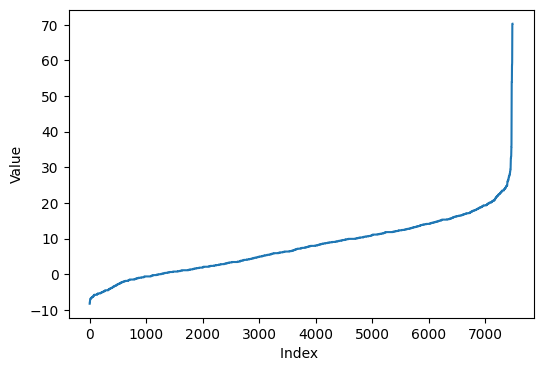

In [158]:
import matplotlib.pyplot as plt
Y_np = Y.detach().cpu().numpy().ravel()  # 拉平成一维
vals_sorted = np.sort(Y_np)              # 升序排序
plt.figure(figsize=(6, 4))
plt.plot(vals_sorted)
plt.xlabel('Index ')
plt.ylabel('Value')

In [27]:
import julia
psmodel = PySRRegressor(
    
    # 1. 核心搜索参数：增加迭代次数，扩大搜索范围
    niterations=50,  # 迭代次数
    population_size=50,  # 每代种群大小
    tournament_selection_n=2,  # 选择压力（较小值鼓励探索）
    
    # 2. 扩展函数基：覆盖更多数学形式
    unary_operators=[
        "square",    # x²
        "cube",      # x³
        "exp",       # e^x
        "log",       # log(x)
        "abs",       # |x|
        "inv",  
        "identity",  # 
    ],
    binary_operators=[
        "+",         # x + y
        "*",         # x * y
        "-",         # x - y
        "less",         
        "iflt_3",
        #"protected_div",  # x / y（当y≈0时返回1，避免数值错误）
    ],

    complexity_of_operators={
        "iflt_3": 1.0,  # 值任意，但必须存在
        # 可选：为其他运算符设置复杂度
        "+": 1.0,
        "*": 1.0,
        "-": 1.0,
        "less": 1.0,
    },
    
    extra_sympy_mappings={
        "iflt_3": lambda x, y, z: sp.Piecewise((y, x), (z, True))
    },
    
    # 3. 约束复杂度：防止过拟合，保证表达式简洁
    maxsize=12,  # 表达式最大长度（默认20，限制过复杂表达式）
    maxdepth=8,  # 表达式最大深度（控制嵌套复杂度）
    
    # 4. 实用配置：提升可读性和可复现性
    random_state=42,  # 固定随机种子，结果可复现
    progress=True,    # 显示实时进度（默认True）
    #elementwise_loss="mse_loss",       # 损失函数（默认MSE，适合回归问题）
)

In [37]:
import sympy as sp
from pysr import PySRRegressor

psmodel = PySRRegressor(
    # 1. 核心搜索参数
    niterations=50,
    population_size=50,
    tournament_selection_n=2,
    
    # 2. 扩展函数基
    unary_operators=[
        "square",    # x²
        "cube",      # x³
        "exp",       # e^x
        "log",       # log(x)（配合abs避免负数）
        "abs",       # |x|（分段线性，增加灵活性）
        "inv",  
        "identity",  # 新增：帮助学习线性项
    ],
    binary_operators=[
        "+",         # x + y
        "*",         # x * y
        "-",         # x - y
        # 注意：这里不再包含 "iflt_3"
    ],
    # 3. 使用内置 ifelse
    extra_sympy_mappings={
        "ifelse": lambda cond, a, b: sp.Piecewise((a, cond), (b, True))
    },
    
    # 4. 约束复杂度
    maxsize=12,
    maxdepth=8,
    
    # 5. 实用配置
    random_state=42,
    progress=True,
)

In [171]:
psmodel.fit(X, Y)

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Compiling Julia backend...


[ Info: Started!



Expressions evaluated per second: 3.490e+04
Head worker occupation: 5.4%
Progress: 11 / 750 total iterations (1.467%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           8.470e+01  1.594e+01  y = x₀
2           4.313e+01  6.748e-01  y = square(x₀)
3           1.548e+01  1.025e+00  y = x₀ * 5.5142
5           1.413e+01  4.579e-02  y = (2.6127 + x₀) * x₀
6           1.359e+01  3.843e-02  y = log(x₀) + (x₀ * 5.2138)
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.310e+04
Head worker occupation: 1.7%
Progress: 23 / 750 total iterations (3.067%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           8.470e+01  1.594e+01  y = x

PySRRegressor.equations_ = [
	   pick     score                              equation       loss  complexity
	0        0.000000                              5.514185  65.123900           1
	1        0.412064                            square(x0)  43.130400           2
	2        1.024569                         x0 * 5.514185  15.481701           3
	3        1.503476                    log(x0) * 17.46633   3.442449           4
	4  >>>>  0.851048           -8.837478 + (x0 * 9.858016)   1.469813           5
	5        0.028710            (14.963006 + x0) * log(x0)   1.428216           6
	6        0.102991  (x0 + -0.9964065) * (13.897214 - x0)   1.288443           7
]

In [14]:
import julia
print("PySR版本：", pysr.__version__)

PySR版本： 0.19.4


In [172]:
best_equation = model.get_best()
print(best_equation)
best_equation.equation

complexity                                             5
loss                                            1.469813
score                                           0.851048
equation                     -8.837478 + (x0 * 9.858016)
sympy_format                      x0*9.858016 - 8.837478
lambda_format    PySRFunction(X=>x0*9.858016 - 8.837478)
Name: 4, dtype: object


'-8.837478 + (x0 * 9.858016)'

In [38]:
X=Input_1['TRAIN TT'].values
Y=output_1['TRAIN TT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Compiling Julia backend...


[ Info: Started!



Expressions evaluated per second: 3.530e+04
Head worker occupation: 2.3%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           4.313e+01  7.971e+00  y = square(x₀)
4           2.490e+01  2.747e-01  y = square(x₀ - -0.51515)
5           3.550e+00  1.948e+00  y = log(cube(cube(square(x₀))))
7           1.664e+00  3.788e-01  y = log(cube(cube(square(x₀)) + 0.24378))
8           1.651e+00  8.005e-03  y = log(cube(square(cube(x₀)) - cube(-0.43018)))
11          1.516e+00  2.835e-02  y = identity(log(cube(identity(square(cube(x₀)))) + cube(cube(...
                                  x₀))))
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.840e+04
Head worker occupation: 0.1%
Progress: 21 / 750 total 

PicklingError: Can't pickle identity: attribute lookup identity on __main__ failed

In [9]:
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

complexity                                                      12
loss                                                      0.128758
score                                                     0.438846
equation         log(cube(x0)) * (log(square(x0)) + exp(1.31310...
sympy_format            (log(x0**2) + 4.16372490584729)*log(x0**3)
lambda_format    PySRFunction(X=>(log(x0**2) + 4.16372490584729...
Name: 7, dtype: object


'log(cube(x0)) * (log(square(x0)) + exp(1.3131009 * 1.0862913))'

In [175]:
X=Input_1['TRAIN HE'].values
Y=output_1['TRAIN HE'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = model.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 750 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 6.170e+02
Head worker occupation: 12.5%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           1.719e+00  7.971e+00  y = exp(1.8445)
3           1.566e+00  9.344e-02  y = 2.5916 * 2.5916
4           8.234e-01  6.427e-01  y = exp(1.9716) - x₀
5           4.108e-02  2.998e+00  y = (2.9931 - x₀) * 2.9931
6           6.098e-04  4.210e+00  y = (x₀ * -3.3413) + cube(2.0839)
-----------

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'C:\\Users\\ET_DY\\AppData\\Local\\Temp\\tmp_5e20iv1'

In [10]:
X=Input_1['TRAIN VOT'].values
Y=output_1['TRAIN VOT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 750 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.310e+03
Head worker occupation: 5.6%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           1.638e+00  7.971e+00  y = square(3.7913)
6           1.411e+00  3.732e-02  y = exp(inv(0.37097)) + abs(x₀)
7           9.031e-01  4.460e-01  y = log(exp(x₀)) + square(inv(-0.26253))
8           4.862e-01  6.193e-01  y = log(square(cube(square(inv(0.32128))))) + x₀
10          3.564e-01  

'x0 + (square(x0) + (13.698899 - (x0 * (0.8162769 * x0))))'

In [176]:
best_equation.equation

'(x0 + 2.5156908) * (x0 + 7.148809)'

In [14]:
X=Input_1['SM TT'].values
Y=output_1['SM TT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Compiling Julia backend...


[ Info: Started!



Expressions evaluated per second: 1.040e+04
Head worker occupation: 40.6%. This is high, and will prevent efficient resource usage. Increase `ncycles_per_iteration` to reduce load on head worker.
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           3.303e+01  1.594e+01  y = -0.67788
2           1.191e+01  1.020e+00  y = inv(0.295)
3           6.920e+00  5.427e-01  y = 2.5782 * x₀
4           8.595e-01  2.086e+00  y = x₀ * cube(1.6761)
5           7.836e-01  9.256e-02  y = x₀ + (3.9756 * x₀)
6           5.505e-01  3.531e-01  y = exp(1.6457) * (x₀ - 0.16715)
7           1.780e-01  1.129e+00  y = (x₀ * 6.185) + (-0.18517 + -1.287)
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.230e+04
Head wo

NotFittedError: This PySRRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [39]:
X=Input_1['SM CO'].values
Y=output_1['SM CO'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 750 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.320e+03
Head worker occupation: 2.8%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           8.598e+01  1.594e+01  y = x₀
2           6.096e+01  3.439e-01  y = square(x₀)
4           4.738e+01  1.260e-01  y = square(1.6206 * x₀)
5           4.482e+01  5.552e-02  y = square(identity(1.4988) * x₀)
6           3.771e+01  1.727e-01  y = -1.1013 + (2.2525 * square(x₀))
7           1.

PicklingError: Can't pickle identity: attribute lookup identity on __main__ failed

In [16]:
X=Input_1['SM HE'].values
Y=output_1['SM HE'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 7.360e+02
Head worker occupation: 7.7%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           2.668e-02  7.971e+00  y = exp(1.8104)
3           1.496e-02  5.788e-01  y = abs(inv(-0.17089))
4           2.763e-03  1.689e+00  y = square(2.4726) - x₀
5           6.039e-04  1.521e+00  y = 4.0975 + (2.0626 - x₀)
6           2.017e-04  1.097e+00  y = cube(x₀) + (6.148 - x₀)
7           0.000e+00  1.594e+01  y = (6.1 + x₀) + (x₀ * -1.7)
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.040e+03
Head worker occupation: 0.0%
Progress: 21 / 750 total iterations (2.800%)
Hall of Fame:
------------------------------------------------------------------------------------------

'(x0 * -0.7000016) + 6.1000004'

In [ ]:
X=Input_1['SM SEATS'].values
Y=output_1['SM SEATS'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.740e+02
Head worker occupation: 5.8%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           3.359e-01  7.971e+00  y = inv(-0.11239)
3           3.388e-02  2.294e+00  y = -4.9291 - 4.5183
4           3.289e-02  2.970e-02  y = inv(-0.10855) - x₀
5           0.000e+00  1.594e+01  y = (-0.57 * x₀) + -9.38
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.140e+02
Head worker occupation: 0.0%
Progress: 21 / 750 total iterations (2.800%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           3.388e-02  7.971e+00  y = cube(-2.114)
4           3.289e-02  1.

In [ ]:
X=Input_1['SM VOT'].values
Y=output_1['SM VOT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.000e+02
Head worker occupation: NaN%
Progress: 2 / 750 total iterations (0.267%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           3.112e+00  7.971e+00  y = exp(1.7438)
5           2.358e-01  8.600e-01  y = abs(x₀) + square(-2.1868)
11          1.886e-01  3.721e-02  y = abs(x₀ + inv((-4.3125 * x₀) - 2.2052)) + 4.8334
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.180e+02
Head worker occupation: 0.0%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           2.440e+01  1.594e+01  y = 1.5141
2           3.035e+00  2.084e+00  y = exp(1.8681)
3    

In [6]:
X=Input_1['CAR TT'].values
Y=output_1['CAR TT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Compiling Julia backend...


[ Info: Started!



Expressions evaluated per second: 4.860e+04
Head worker occupation: 35.6%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           5.485e+02  1.594e+01  y = 0.57405
2           2.001e+01  3.311e+00  y = square(4.8541)
3           1.342e+01  3.994e-01  y = 22.317 + x₀
6           6.383e+00  2.477e-01  y = square(cube(-1.668)) + square(x₀)
9           3.308e+00  2.191e-01  y = abs(square(exp(1.4336))) + (exp(1.4336) * x₀)
10          3.154e+00  4.787e-02  y = log(cube(cube(exp(2.0132))) * square(square(exp(x₀))))
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 5.020e+04
Head worker occupation: 2.3%
Progress: 21 / 750 total iterations (2.800%)
Hall of Fame:
------------------------------------------

'square((0.4720814 * x0) - -4.2464495)'

In [63]:
X=Input_1['CAR CO'].values
Y=output_1['CAR CO'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

Compiling Julia backend...


C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.150e+04
Head worker occupation: 3.5%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           1.359e+02  7.971e+00  y = cube(-2.25)
3           4.810e+01  1.039e+00  y = cube(inv(-0.3749))
4           3.732e+01  2.537e-01  y = x₀ - cube(2.7739)
5           3.091e+01  1.883e-01  y = cube(x₀) - abs(22.317)
6           2.763e+01  1.124e-01  y = cube(-3.5046 + x₀) - x₀
8           1.678e+01  2.492e-01  y = cube(-3.2846 + abs(x₀)) + inv(-0.73729)
9           2.541e+00  1.888e+00  y = (x₀ - ((2.7394 + x₀) - x₀)) * 10.299
10          9.383e-01  9.961e-01  y = cube(-3.12) - (abs(abs(-1.7107) * x₀) * -6.929)
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.430e+04
Head

'cube(abs(-0.5581123 * x0) + -3.166874)'

In [64]:
X=Input_1['CAR VOT'].values
Y=output_1['CAR VOT'].values
X=torch.tensor(X).unsqueeze(1)
Y=torch.tensor(Y).unsqueeze(1)
psmodel.fit(X, Y)
best_equation = psmodel.get_best()
print(best_equation)
best_equation.equation

C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1989: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
C:\py\anaconda3\envs\dxtorch\lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 750 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.320e+03
Head worker occupation: 4.4%
Progress: 9 / 750 total iterations (1.200%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           3.453e+01  7.971e+00  y = inv(-0.23309)
3           9.806e+00  1.259e+00  y = cube(cube(-1.2812))
4           8.619e+00  1.290e-01  y = x₀ - exp(2.185)
5           7.744e+00  1.071e-01  y = x₀ - exp(square(1.5166))
6           3.439e+00  8.116e-01  y = cube(x₀ - abs(exp(0.98828)))
7     

PicklingError: Can't pickle inv: attribute lookup inv on __main__ failed

In [40]:
from torch.autograd import grad
import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import torch.nn.functional as F
def cal_loss(model, x, z, y, GR, base, lambd, criterion):
    '''
    仅对ChoiceModel中的PN1施加梯度约束
    
    参数:
    - model: ChoiceModel实例
    - x: 模型输入x（用于FeatureProduce生成x1/x2/x3）
    - z: 模型输入z（用于WeightNN）
    - y: 标签
    - GR: 梯度正则类型（'UGR'/'PGR'/'LGR'/'none'）
    - base: 正则项计算方式（'sum'或其他，对应正梯度和或平方和）
    - lambd: 正则项权重
    - criterion: 基础损失函数（如交叉熵）
    '''
    # 1. 计算基础损失（基于模型最终输出）
    
    choice_probabilities = model(x, z)  # 模型输出：选择概率
    log_probs = torch.log(choice_probabilities)  # NLLLoss需要对数概率
    loss = criterion(log_probs, y)
    
    # 若无需梯度约束，直接返回基础损失
    if GR == None :
        return loss
    
    # 2. 提取PN1的输入和输出（用于计算梯度）
    # 2.1 生成中间特征x1/x2/x3（与ChoiceModel.forward逻辑一致）
    x1, x2, x3 = model.feature_produce(x)
    # 处理可能的NaN（与模型内部保持一致）
    x1[torch.isnan(x1)] = 0
    x2[torch.isnan(x2)] = 0
    x3[torch.isnan(x3)] = 0
    #print(f'execute grad constrain')
    # 2.2 记录每个PN1的输出（共12个）
    pn1_outputs = []
    # PN1[0-3]对应x1的0-3列
    for i in range(4):
        pn1_out = model.PN1[i](x1[:, i])  # x1[:,i]是PN1[i]的输入
        pn1_outputs.append(pn1_out)
    # PN1[4-8]对应x2的0-4列
    for i in range(5):
        pn1_out = model.PN1[4+i](x2[:, i])  # x2[:,i]是PN1[4+i]的输入
        pn1_outputs.append(pn1_out)
    # PN1[9-11]对应x3的0-2列
    for i in range(3):
        pn1_out = model.PN1[9+i](x3[:, i])  # x3[:,i]是PN1[9+i]的输入
        pn1_outputs.append(pn1_out)
    
    # 3. 根据GR类型计算梯度正则项
    # 3.1 定义需要关注的输入特征（这里直接使用PN1的直接输入x1/x2/x3的对应列）
    pn1_inputs = []
    pn1_inputs.extend([x1[:, i] for i in range(4)])  # PN1[0-3]的输入
    pn1_inputs.extend([x2[:, i] for i in range(5)])  # PN1[4-8]的输入
    pn1_inputs.extend([x3[:, i] for i in range(3)])  # PN1[9-11]的输入
    
    # 3.2 计算每个PN1输出对其输入的梯度
    grads = []
    for idx in range(12):  # 遍历12个PN1
        out = pn1_outputs[idx]  # 第idx个PN1的输出
        inp = pn1_inputs[idx]   # 第idx个PN1的输入（x1/x2/x3的某一列）
        # 计算梯度（create_graph=True确保二阶导数可求，用于后续反向传播）
        g = grad(
            out, inp, 
            grad_outputs=torch.ones_like(out),  # 梯度权重为1
            create_graph=True, 
            retain_graph=True,
            allow_unused=True  # 允许未使用的输入，避免报错
        )[0]  # 返回梯度张量（形状与inp一致）
        if g is None:
            # 生成与输入形状相同的零张量，且在同一设备上
            g = torch.zeros_like(inp, device=inp.device)
        grads.append(g)  # 此时grads中全是张量，无None

    for idx, (out, inp) in enumerate(zip(pn1_outputs, pn1_inputs)):
        # 检查输入是否在计算图中被使用
        if not inp.grad_fn:
            print(f"警告：PN1[{idx}]的输入特征未参与计算（可能是代码逻辑错误）")
            
    # 4. 聚合梯度并计算正则项（根据base选择计算方式）
    if base == 'sum':
        # 仅累加正梯度（例如约束PN1输出随输入增大而单调递增）
        reg = sum(g[g <= 0].sum() for g in grads)
    else:
        # L2正则（惩罚过大梯度，保证平滑性）
        reg = sum(torch.pow(g, 2).sum() for g in grads)
    
    # 5. 总损失 = 基础损失 + PN1的梯度正则项
    return loss + lambd * reg

class PN1(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, final_hidden_size=64, output_size=1):
        super(PN1, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.softplus1 = nn.Softplus()  # 替换原有的ReLU
        
        self.fc2 = nn.Linear(hidden_size, final_hidden_size)
        self.softplus2 = nn.Softplus()  # 替换原有的Sigmoid
        
        self.fc3 = nn.Linear(final_hidden_size, output_size)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # 扩展维度：[batch_size] → [batch_size, 1]
        out = self.fc1(x)
        out = self.softplus1(out)  # 使用Softplus激活
        
        out = self.fc2(out)
        out = self.softplus2(out)  # 第二层也使用Softplus
        
        out = self.fc3(out)
        return out
        
class WeightNN(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size0=5, output_size1=6, output_size2=4):
        super(WeightNN, self).__init__()
        self.hidden1 = nn.Linear(input_size, hidden_size1)
        self.hidden2_para1 = nn.Linear(hidden_size1, hidden_size2)
        self.hidden2_para2 = nn.Linear(hidden_size1, hidden_size2)
        self.hidden2_para3 = nn.Linear(hidden_size1, hidden_size2)
        self.output0 = nn.Linear(hidden_size2, output_size0)
        self.output1 = nn.Linear(hidden_size2, output_size1)
        self.output2 = nn.Linear(hidden_size2, output_size2)
        self.output3 = nn.Linear(hidden_size1, 3)

    def forward(self, z):
        N = len(z)
        f2 = torch.zeros(N, 12, device=z.device)
        f4 = torch.zeros(N, 3, device=z.device)
        f = F.leaky_relu(self.hidden1(z))
        f1_0 = F.leaky_relu(self.hidden2_para1(f))
        f2_0 = torch.sigmoid(self.output0(f1_0))
        f1_1 = F.leaky_relu(self.hidden2_para2(f))
        f2_1 = torch.sigmoid(self.output1(f1_1))
        f1_2 = F.leaky_relu(self.hidden2_para3(f))
        f2_2 = torch.sigmoid(self.output2(f1_2))
        f3 = self.output3(f)

        f2[:, 0] = -f2_0[:, 0]
        f2[:, 1] = -f2_0[:, 1]
        f2[:, 2] = f2_0[:, 2]
        f2[:, 3] = f2_0[:, 3]
        f2[:, 4] = -f2_1[:, 0]
        f2[:, 5] = -f2_1[:, 1]
        f2[:, 6] = f2_1[:, 2]
        f2[:, 7] = f2_1[:, 3]
        f2[:, 8] = f2_1[:, 4]
        f2[:, 9] = -f2_2[:, 0]
        f2[:, 10] = -f2_2[:, 1]
        f2[:, 11] = f2_2[:, 2]
        
        f4[:,0] = f2_0[:, 4]
        f4[:,1] = f2_1[:, 5]
        f4[:,2] = f2_2[:, 3]
        
        

        return f2, f4, f3

class FeatureProduce(nn.Module):
    def __init__(self):
        super(FeatureProduce, self).__init__()

    def forward(self, x):
        # 直接从x构造x1/x2/x3，避免用torch.zeros（防止梯度断裂）
        # x1: 前3列 + 第1列/第0列（形状：[N,4]）
        x1 = torch.cat([
            x[:, 0:3],  # 前3列（直接来自x，保留梯度）
            (x[:, 1] / x[:, 0]).unsqueeze(1)  # 第3列（除法操作，保留梯度）
        ], dim=1)
        
        # x2: 第3-6列 + 第4列/第3列（形状：[N,5]）
        x2 = torch.cat([
            x[:, 3:7],  # 第3-6列
            (x[:, 4] / x[:, 3]).unsqueeze(1)  # 第4列
        ], dim=1)
        
        # x3: 第7-8列 + 第8列/第7列（形状：[N,3]）
        x3 = torch.cat([
            x[:, 7:9],  # 第7-8列
            (x[:, 8] / x[:, 7]).unsqueeze(1)  # 第2列
        ], dim=1)
        
        # 处理NaN（用0填充，但保留梯度）
        x1 = torch.where(torch.isnan(x1), torch.zeros_like(x1), x1)
        x2 = torch.where(torch.isnan(x2), torch.zeros_like(x2), x2)
        x3 = torch.where(torch.isnan(x3), torch.zeros_like(x3), x3)
        
        return x1, x2, x3
    
class ChoiceModel(nn.Module):
    def __init__(self):
        super(ChoiceModel, self).__init__()
        self.WeightNN = self.WeightNN = WeightNN(input_size=25, hidden_size1=100, hidden_size2=100, output_size0=5, output_size1=6, output_size2=4)
        self.PN1 = nn.ModuleList([PN1() for _ in range(12)])
        self.feature_produce = FeatureProduce()


    def forward(self, x, z):
        weight1, weight2, bias = self.WeightNN(z)
        x1, x2, x3 = self.feature_produce(x)

        
        x1[torch.isnan(x1)] = 0
        x2[torch.isnan(x2)] = 0
        x3[torch.isnan(x3)] = 0
        #print(f"Shape of x1(:,1): {x1[:,1].shape}")
        
        w1 = weight1[:, 0:4]
        w2 = weight1[:, 4:9]
        w3 = weight1[:, 9:12]
        #print(np.shape(w1))

        b1 = bias[:, 0].unsqueeze(1)
        b2 = bias[:, 1].unsqueeze(1)
        b3 = bias[:, 2].unsqueeze(1)
        
        expr1 = (x1[:,0] - 0.9739631) * (13.572 - 3 * torch.log(x1[:,0]))
        expr2 = (x1[:,1] + 2.52) * (x1[:,1] + 7.15)  # 修正常数项以匹配MATLAB
        expr3 = -3.34 * x1[:,2] + 9.05  # 简化表达式，与MATLAB等效
        expr4 = 0.18372 * (x1[:,3] ** 2) + x1[:,3] + 13.699  # 修正为二次函数形式
        expr5 = 4.96 * x2[:,0] + torch.log(x2[:,0])  # 修正系数以匹配MATLAB
        expr6 = 12.05 * x2[:,1] - 12.09  # 简化常数项（abs(-12.086)≈12.09）
        expr7 = -0.7 * x2[:,2] + 6.1  # 与MATLAB一致，无需修改
        expr8 = -0.57 * x2[:,3] - 9.38  # 与MATLAB一致，无需修改
        expr9 = 0.03841 * (x2[:,4] + 6.8789) **2 + 3.4306  # 修正为二次函数形式
        expr10 = (0.472 * x3[:,0] + 4.246)** 2  # 修正为平方形式
        expr11 = (0.5581123 * x3[:,1] - 3.166874) **3  # 修正为三次函数形式
        expr12 = (0.70374 * x3[:,2] - 2.4738)** 3  # 修正为三次函数形式

       

        F1 = (w1[:, 0].unsqueeze(1) * expr1.unsqueeze(1) + w1[:, 1].unsqueeze(1) * expr2.unsqueeze(1) + w1[:, 2].unsqueeze(1) * expr3.unsqueeze(1) + 
        w1[:, 3].unsqueeze(1) * expr4.unsqueeze(1) + b1)
        F2 = (w2[:, 0].unsqueeze(1) * expr5.unsqueeze(1) + w2[:, 1].unsqueeze(1) * expr6.unsqueeze(1) + w2[:, 2].unsqueeze(1) * expr7.unsqueeze(1) + 
        w2[:, 3].unsqueeze(1) * expr8.unsqueeze(1)  + w2[:, 4].unsqueeze(1) * expr9.unsqueeze(1)+b2)
        F3 = w3[:, 0].unsqueeze(1) * expr10.unsqueeze(1) + w3[:, 1].unsqueeze(1) * expr11.unsqueeze(1) + w3[:, 2].unsqueeze(1) * expr12.unsqueeze(1) + b3

        #print(f'shape F1: {F1.shape}')
        

        utilities = torch.cat([F1, F2, F3], dim=1)
        #print(f"Shape of utilities: {utilities.size()}")
        choice_probabilities = F.softmax(utilities,dim=1)
        return choice_probabilities
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ChoiceModel()
model.to(device)

ChoiceModel(
  (WeightNN): WeightNN(
    (hidden1): Linear(in_features=25, out_features=100, bias=True)
    (hidden2_para1): Linear(in_features=100, out_features=100, bias=True)
    (hidden2_para2): Linear(in_features=100, out_features=100, bias=True)
    (hidden2_para3): Linear(in_features=100, out_features=100, bias=True)
    (output0): Linear(in_features=100, out_features=5, bias=True)
    (output1): Linear(in_features=100, out_features=6, bias=True)
    (output2): Linear(in_features=100, out_features=4, bias=True)
    (output3): Linear(in_features=100, out_features=3, bias=True)
  )
  (PN1): ModuleList(
    (0-11): 12 x PN1(
      (fc1): Linear(in_features=1, out_features=64, bias=True)
      (softplus1): Softplus(beta=1.0, threshold=20.0)
      (fc2): Linear(in_features=64, out_features=64, bias=True)
      (softplus2): Softplus(beta=1.0, threshold=20.0)
      (fc3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (feature_produce): FeatureProduce()
)

In [41]:
x_train = x_train.to(device)
z_train = z_train.to(device)
label_train = label_train.to(device)
print("Model device:", next(model.parameters()).device)
print("x_train device:", x_train.device)
print("z_train device:", z_train.device)
print("label_train device:", label_train.device)
print(model(x_train, z_train))
print(np.shape(model(x_train, z_train)))

Model device: cuda:0
x_train device: cuda:0
z_train device: cuda:0
label_train device: cuda:0
tensor([[4.4990e-02, 9.5490e-01, 1.0945e-04],
        [1.1254e-02, 9.8816e-01, 5.8978e-04],
        [6.8639e-03, 9.9276e-01, 3.7646e-04],
        ...,
        [6.3363e-03, 9.9330e-01, 3.6440e-04],
        [2.9999e-03, 9.9653e-01, 4.6949e-04],
        [5.1951e-03, 9.9464e-01, 1.6487e-04]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
torch.Size([7484, 3])


In [42]:
from torchmetrics.functional.classification import multiclass_f1_score
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.NLLLoss(reduction='mean')  # 基础损失：负对数似然
n_epochs = 1
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = MultiStepLR(optimizer, milestones=[0.5 * n_epochs, 0.75 * n_epochs], gamma=0.1)

# 梯度约束参数（可根据需求调整）
#GR = None  # 梯度正则类型（基于PN1输出的梯度）
GR = 'UGR'
base = 'sum'  # 正则项计算方式（正梯度和）
lambd = 0.1  # 正则项权重（控制约束强度）

# ----------------------
# 3. 训练函数（含梯度约束）
# ----------------------
def evaluate(model, data_loader, criterion, device):
    """计算数据集的准确率、F1分数、平均NLL损失"""
    model.eval()
    correct = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, z, y in data_loader:
            x = x.to(device)
            z = z.to(device)
            y = y.to(device)
            
            output = model(x, z)
            pred = output.argmax(-1)
            y = torch.argmax(y, dim=1)  # one-hot转类别索引
            
            correct += pred.eq(y).sum().item()
            log_probs = torch.log(output)
            total_loss += criterion(log_probs, y).item() * x.size(0)
            
            all_preds.append(pred.cpu())
            all_labels.append(y.cpu())
    
    total = len(data_loader.dataset)
    acc = correct / total
    avg_loss = total_loss / total
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    print(f'all_labels : {all_labels}')
    print(f'all_preds : {all_preds}')
    f1 = multiclass_f1_score(all_labels, all_preds, num_classes=3)
    
    return acc, f1, avg_loss

# ----------------------
# 3. 训练参数与主循环
# ----------------------
Loss_2=[]
# ----------------------
# 4. 训练函数（仅负责训练，不打印指标）
# ----------------------
def train(model, train_loader, optimizer, criterion, device, GR, base, lambd, n_epochs):
    model.train()
    Loss_2=[]
    for epoch in range(n_epochs):
        for x, z, y in train_loader:
            x = x.to(device)
            z = z.to(device)
            y = y.to(device)
            y = torch.argmax(y, dim=1)  # 处理标签
            x.requires_grad_(True)  # 新增此行，开启x的梯度跟踪
            
            optimizer.zero_grad()
            loss = cal_loss(model, x, z, y, GR, base, lambd, criterion)
            loss.backward()
            optimizer.step()
        Loss_2.append(loss.detach().cpu().item())
        scheduler.step()  # 每轮结束后更新学习率
    print(f"训练完成（共 {n_epochs} 轮），NLL 为{loss}")
    return Loss_2

In [43]:
# 5. 执行训练并在结束后输出指标
# ----------------------
# 开始训练（无中间打印）
_=train(model, data_loader1, optimizer, criterion, device, GR, base, lambd, n_epochs=2000)

# 训练结束后，分别评估训练集和测试集
train_acc, train_f1, train_nll = evaluate(model, data_loader1, criterion, device)
test_acc, test_f1, test_nll = evaluate(model, data_loader2, criterion, device)

# 统一输出结果
print("\n" + "="*50)
print("最终指标对比")
print("-"*50)
print(f"训练集：")
print(f"  准确率：{train_acc:.4f} ({100*train_acc:.1f}%)")
print(f"  F1分数：{train_f1:.4f}")
print(f"  NLL损失：{train_nll:.4f}")
print("-"*50)
print(f"测试集：")
print(f"  准确率：{test_acc:.4f} ({100*test_acc:.1f}%)")
print(f"  F1分数：{test_f1:.4f}")
print(f"  NLL损失：{test_nll:.4f}")
print("="*50)

训练完成（共 2000 轮），NLL 为0.38760194182395935
all_labels : tensor([1, 1, 2,  ..., 1, 2, 1])
all_preds : tensor([1, 1, 2,  ..., 1, 2, 1])
all_labels : tensor([1, 1, 1,  ..., 1, 0, 1])
all_preds : tensor([1, 2, 1,  ..., 1, 1, 1])

最终指标对比
--------------------------------------------------
训练集：
  准确率：0.8260 (82.6%)
  F1分数：0.7973
  NLL损失：0.3874
--------------------------------------------------
测试集：
  准确率：0.7728 (77.3%)
  F1分数：0.7314
  NLL损失：0.6279


In [57]:
total_loss2 =[]

for i in range(10):
    # 训练模型，会更新全局变量Loss_（张量类型）
    model = ChoiceModel()
    model.to(device)
    criterion = nn.NLLLoss(reduction='mean')  # 基础损失：负对数似然
    n_epochs = 1
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = MultiStepLR(optimizer, milestones=[0.5 * n_epochs, 0.75 * n_epochs], gamma=0.1)
    Loss_2= train(model, data_loader1, optimizer, criterion, device, GR, base, lambd, n_epochs=2000)
    total_loss2.append( Loss_2)

训练完成（共 2000 轮），NLL 为0.3937404155731201
训练完成（共 2000 轮），NLL 为0.39365118741989136
训练完成（共 2000 轮），NLL 为0.3904164731502533
训练完成（共 2000 轮），NLL 为0.39105403423309326
训练完成（共 2000 轮），NLL 为0.395885705947876
训练完成（共 2000 轮），NLL 为0.397202730178833
训练完成（共 2000 轮），NLL 为0.39401257038116455
训练完成（共 2000 轮），NLL 为0.397941529750824
训练完成（共 2000 轮），NLL 为0.3959139883518219
训练完成（共 2000 轮），NLL 为0.3928465247154236


In [55]:
total_loss2

[[], [], [], [], [], [], [], [], [], []]

In [58]:
file_path = 'C:/Users/ET_DY/Desktop/paper/MINE/nn-sr/PN1_GRAD_CONSTRAIN/total_loss_2.csv'   
np.savetxt(file_path, total_loss2, delimiter=',')

In [92]:
criterion = nn.NLLLoss(reduction='mean')  # 使用负对数似然损失
from torchmetrics.functional.classification import multiclass_f1_score
#optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
n_epochs = 1
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = MultiStepLR(optimizer, milestones=[0.5 * n_epochs, 0.75 * n_epochs], gamma=0.1)
def train(epoch):
    model.train()
    for x, z, y in data_loader1:
        # 将数据移动到GPU
        x = x.to(device)
        z = z.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        y = torch.argmax(y, dim=1)  # 确保y也在GPU上
        output = model(x, z)        # 模型的前向传播在GPU上执行
        log_probs = torch.log(output)
        loss = criterion(log_probs, y)      # 损失计算也在GPU上执行
        loss.backward()              # 反向传播在GPU上执行
        optimizer.step()
        loss = loss.item()           # 将loss移回CPU以进行打印
    return loss

def test():
    model.eval()
    correct = 0
    for x, z, y in data_loader2:
        # 将数据移动到GPU
        x = x.to(device)
        z = z.to(device)
        y = y.to(device)

        output = model(x, z)  # 预测也在GPU上执行
        pred = output.argmax(-1)
        y = torch.argmax(y, dim=1)
        correct += pred.eq(y.view_as(pred)).cpu().sum()  # 将结果移回CPU以进行比较

        # 测试集上的损失计算
        pred2 = model(x, z)
        log_probs2 = torch.log(pred2)
        loss = criterion(log_probs2, y)
        f1 = multiclass_f1_score(y, pred, num_classes=3)  # 确保f1_score计算也在CPU上执行
        acc = correct / float(len(data_loader2.dataset))
        
        print('Epoch: {}, Test set: Accuracy: {}/{} ({:.0f}%), F1 Score: {:.4f}, NNL: {:.4f}'.format(
              epoch, correct, len(data_loader2.dataset), 100. * correct / float(len(data_loader2.dataset)), f1, loss.item()))
    return f1, acc, loss

In [93]:
F1=[]
AC=[]
Loss_1=[]
Loss=[]
n_epochs=2000
from tqdm.notebook import tqdm
for epoch in range(1, n_epochs + 1):
    loss=train(epoch)
    Loss_1.append(loss)

In [94]:
f1,acc,loss=test()
F1.append(f1)
AC.append(acc)
Loss.append(loss)
scheduler.step()
state_dict = model.state_dict()

Epoch: 2000, Test set: Accuracy: 2453/3208 (76%), F1 Score: 0.7148, NNL: 0.6389


In [95]:
Loss_1[1900:2000]

[0.4057875871658325,
 0.4057837128639221,
 0.4053259789943695,
 0.40442320704460144,
 0.4039153754711151,
 0.4040316343307495,
 0.404499888420105,
 0.4049406945705414,
 0.40481236577033997,
 0.40439727902412415,
 0.40381288528442383,
 0.403504878282547,
 0.4035445749759674,
 0.40377599000930786,
 0.40399691462516785,
 0.403984397649765,
 0.40382489562034607,
 0.40354129672050476,
 0.40333008766174316,
 0.40324920415878296,
 0.4032970070838928,
 0.4034074544906616,
 0.40349939465522766,
 0.4035373330116272,
 0.4034963846206665,
 0.40341341495513916,
 0.40331175923347473,
 0.403229683637619,
 0.4032000005245209,
 0.4032471776008606,
 0.4033873379230499,
 0.40363550186157227,
 0.40404045581817627,
 0.4045933187007904,
 0.40543046593666077,
 0.4064391851425171,
 0.4078318774700165,
 0.4093479514122009,
 0.41103631258010864,
 0.4126114249229431,
 0.4135318696498871,
 0.4132792353630066,
 0.41123127937316895,
 0.4076768755912781,
 0.404224693775177,
 0.40242746472358704,
 0.40286317467689514

In [ ]:
def cal_loss(model, X, y, GR, base, lambd, criterion):
    '''
    Function to regularize the loss function
    lambd: weight of GR -> (1-lambd) is the weight of loss
    base: indicator of regularizing the sum
    '''
    loss = criterion(model(X), y)
    # Utility GR
    if GR == 'UGR':
        utl = model(X)
        g1 = grad(utl[:, 0], X, torch.ones_like(utl[:, 0]), create_graph=True)[0][:, 8:10]
        g2 = grad(utl[:, 1], X, torch.ones_like(utl[:, 1]), create_graph=True)[0][:, 10:12]
        g3 = grad(utl[:, 2], X, torch.ones_like(utl[:, 2]), create_graph=True)[0][:, 12]
    # Probability GR
    elif GR == 'PGR':
        prb = softmax(model(X), dim=1)
        g1 = grad(prb[:, 0], X, torch.ones_like(prb[:, 0]), create_graph=True)[0][:, 8:10]
        g2 = grad(prb[:, 1], X, torch.ones_like(prb[:, 1]), create_graph=True)[0][:, 10:12]
        g3 = grad(prb[:, 2], X, torch.ones_like(prb[:, 2]), create_graph=True)[0][:, 12]
    # Loss GR
    elif GR == 'LGR':
        log_prb = torch.log(softmax(model(X), dim=1))
        g1 = grad(log_prb[:, 0]*(y==0), X, torch.ones_like(log_prb[:, 0]), create_graph=True)[0][:, 8:10]
        g2 = grad(log_prb[:, 1]*(y==1), X, torch.ones_like(log_prb[:, 0]), create_graph=True)[0][:, 10:12]
        g3 = grad(log_prb[:, 2]*(y==2), X, torch.ones_like(log_prb[:, 0]), create_graph=True)[0][:, 12]
    # Without GR
    else:
        return loss

    # Sum- vs. norm-GR
    if base == 'sum':
        reg = g1[g1 > 0].sum() + g2[g2 > 0].sum() + g3[g3 > 0].sum()
    else:
        reg = torch.pow(g1, 2).sum() + torch.pow(g2, 2).sum() + torch.pow(g3, 2).sum()
    return loss + lambd * reg
    
def train_loop(model, GR, base, lambd, optimizer, criterion):
    'Function for DNN training in each epoch'
    for X, y in train_loader:
        loss = cal_loss(model, X, y, GR, base, lambd, criterion)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return loss

def cal_metrics(model, criterion, loader):
    ll = 0
    y_true, y_pred = [], []
    for X, y in loader:
        pred = model(X)
        y_true.extend(y)
        loss = criterion(pred, y).item()
        ll -= loss * len(X)
        y_pred.extend(pred.argmax(1))
    f1 = f1_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    return ll, acc, f1, loss

def test(model, criterion):
    'Function for NN testing'
    model.eval()
    with torch.no_grad():
        # For loss, accuracy, and F1 score calculation
        met_train = cal_metrics(model, criterion, train_loader)
        met_val = cal_metrics(model, criterion, val_loader)
        met_test = cal_metrics(model, criterion, test_loader)

        # For probability calculation
        for X, _ in prb_loader:
            prb = softmax(model(X), dim=1).detach().numpy()

        # For regularity calculation
        for X_train, _ in train_reg_loader:
            prb_reg_train = softmax(model(X_train), dim=1)[:, alt].detach().numpy()
        for X_val, _ in val_reg_loader:
            prb_reg_val = softmax(model(X_val), dim=1)[:, alt].detach().numpy()
        for X_test, _ in test_reg_loader:
            prb_reg_test = softmax(model(X_test), dim=1)[:, alt].detach().numpy()
    return met_train, met_val, met_test, prb, prb_reg_train, prb_reg_val, prb_reg_test

def train(NN, num_epochs, GR, base, lambd):
    'Function for NN training'
    agg_loss, l_met_train, l_met_val, l_met_test, l_prb, l_prb_reg_train, l_prb_reg_val, l_prb_reg_test = [[] for i in range(8)]
    for m in range(1, num_models+1):
        torch.manual_seed(m)
        model = NN()
        l_loss_train_epoch, l_loss_val_epoch = [], []
        optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0)
        criterion = nn.CrossEntropyLoss()
        for i in range(num_epochs):
            l_loss_train_epoch.append(train_loop(model, GR, base, lambd, optimizer, criterion).detach().numpy())
            model.eval()
            with torch.no_grad():
                l_loss_val_epoch.append(cal_metrics(model, criterion, val_loader)[3])
            model.train()
        agg_loss.append([l_loss_train_epoch, l_loss_val_epoch])
        met_train, met_val, met_test, prb, reg_train, reg_val, reg_test = test(model, criterion)
        [x.append(y) for x, y in zip([l_met_train, l_met_val, l_met_test, l_prb, l_prb_reg_train, l_prb_reg_val, l_prb_reg_test],
                                     [met_train, met_val, met_test, prb, reg_train, reg_val, reg_test])]
        print(f'Model {m:<2}')
        print_metrics(met_train, met_val, met_test)
    plot_loss(agg_loss)
    return l_met_train, l_met_val, l_met_test, l_prb, l_prb_reg_train, l_prb_reg_val, l_prb_reg_test

def NN_agg(l_met):
    'Function to analyze aggregate NN performance'
    # Averages
    avg_ll = np.mean([r[0] for r in l_met])
    avg_acc = np.mean([r[1] for r in l_met])
    avg_f1 = np.mean([r[2] for r in l_met])
    # Standard deviations
    std_ll = np.std([r[0] for r in l_met])
    std_acc = np.std([r[1] for r in l_met])
    std_f1 = np.std([r[2] for r in l_met])
    print(f'Average log-likelihood = {avg_ll:.1f} ({std_ll:.1f})')
    print(f'Average accuracy       = {avg_acc:.1%} ({std_acc:.1%})')
    print(f'Average F1 score       = {avg_f1:.1%} ({std_f1:.1%})')
    return [avg_ll, avg_acc, avg_f1], [std_ll, std_acc, std_f1]

def NN_sub(l_prb, NN, base, GR, lambd):
    'Function to plot substitution patterns'
    for a in range(3):
        for p in l_prb[:, :, a]:
            plt.plot(data1_prb[var], p, color=l_color[a], alpha=.10)
        plt.plot(data1_prb[var], np.mean(l_prb[:, :, a], axis=0), color=l_color[a], label=l_alt[a])
    plt.legend(frameon=False)
    plt.xlabel(f'{var} ($)')
    plt.ylabel('Probability')
    if GR == 'none':
        plt.savefig(f'{path}/Regularity_results/{NN.__name__}_10K.png', bbox_inches='tight', dpi=200)
    else:
        plt.savefig(f'{path}/Regularity_results/{NN.__name__}_{base}_{GR}_{lambd}_10K.png', bbox_inches='tight', dpi=200)
    plt.show()

def NN_reg(l_prb_reg):
    'Function to calculate strong and weak regularities for NNs'
    l_st_reg, l_wk_reg = [], []
    for prb_reg in l_prb_reg:
        diff = np.subtract(prb_reg[1::2], prb_reg[::2])
        l_st_reg.append(sum(diff < eps) / len(diff))
        l_wk_reg.append(sum(diff < -eps) / len(diff))
    avg_st_reg = np.mean(l_st_reg)
    avg_wk_reg = np.mean(l_wk_reg)
    std_st_reg = np.std(l_st_reg)
    std_wk_reg = np.std(l_wk_reg)
    print(f'Strong regularity = {avg_st_reg:.3f} ({std_st_reg:.3f})')
    print(f'Weak regularity   = {avg_wk_reg:.3f} ({std_wk_reg:.3f})')
    return [avg_st_reg, avg_wk_reg], [std_st_reg, std_wk_reg]

def comparison(lambdas, agg_ll, agg_acc, agg_f1, l_st_reg, l_wk_reg, NN, base, GR):
    'Function to compare NN models'
    print('-'*30, '\nModel comparison:')
    fig, ax1 = plt.subplots()

    # Plot average test log-likelihood
    ax1.grid(linestyle='--', color='lightgray')
    ax1.plot(np.log10(lambdas), agg_ll, marker='.', color=l_color[0], label='Log-likelihood')
    ax1.set_xlabel(r'
')
    ax1.set_ylabel('Test log-likelihood (average)')

    # Plot average test accuracy
    ax2 = ax1.twinx()
    ax2.plot(np.log10(lambdas), agg_acc, marker='.', color=l_color[1], label='Accuracy')
    ax2.set_ylabel(r'Test accuracy, 
 score, regularities (average)')

    # Plot average test F1 score
    ax2.plot(np.log10(lambdas), agg_f1, marker='.', color=l_color[2], label=r'
 score')

    # Plot average regularities
    ax2.plot(np.log10(lambdas), l_st_reg, marker='.', linestyle='dashed', color=l_color[3], label='Strong regularity')
    ax2.plot(np.log10(lambdas), l_wk_reg, marker='.', linestyle='dashed', color=l_color[4], label='Weak regularity')

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    box = ax1.get_position()
    ax1.legend(h1+h2, l1+l2, frameon=False, loc='upper center', bbox_to_anchor=(.5, -.15), ncol=2)
    fig.savefig(f'{path}/Regularity_results/{NN.__name__}_{base}_{GR}_10K.png', bbox_inches='tight', dpi=200)

def result(NN, num_epochs, GR, lambdas=[0], base='sum'):
    'Function to display all DNN results'
    agg_ll_test, agg_acc_test, agg_f1_test, l_st_reg, l_wk_reg = [[] for i in range(5)]
    for lambd in lambdas:
        print(f'Penalty = {lambd}')
        print('-'*30)
        if NN == DNN and lambd > 1:
            l_met_train, l_met_val, l_met_test, l_prb, l_prb_reg_train, l_prb_reg_val, l_prb_reg_test = train(NN, num_epochs+20, GR, base, lambd)
        else:
            l_met_train, l_met_val, l_met_test, l_prb, l_prb_reg_train, l_prb_reg_val, l_prb_reg_test = train(NN, num_epochs, GR, base, lambd)
        # Average LL, accuracy, and F1 score
        print('-'*30, '\nTraining set:')
        avg_met_train, std_met_train = NN_agg(l_met_train)
        print('-'*30, '\nValidation set:')
        avg_met_val, std_met_val = NN_agg(l_met_val)
        print('-'*30, '\nTest set:')
        avg_met_test, std_met_test = NN_agg(l_met_test)
        [x.append(y) for x, y in zip([agg_ll_test, agg_acc_test, agg_f1_test], avg_met_test)]

        # Regularities
        if GR == 'none':
            name = f'{NN.__name__}'
        else:
            name = f'{NN.__name__}, {base}-{GR} ({lambd})'
        print('-'*30, '\nTraining set:')
        [x.extend(y) for x, y in zip([avg_met_train, std_met_train], NN_reg(l_prb_reg_train))]
        results_train[name] = avg_met_train
        results_train_std[name] = std_met_train
        print('-'*30, '\nValidation set:')
        [x.extend(y) for x, y in zip([avg_met_val, std_met_val], NN_reg(l_prb_reg_val))]
        results_val[name] = avg_met_val
        results_val_std[name] = std_met_val
        print('-'*30, '\nTest set:')
        avg_reg, std_reg = NN_reg(l_prb_reg_test)
        [x.extend(y) for x, y in zip([avg_met_test, std_met_test], [avg_reg, std_reg])]
        results_test[name] = avg_met_test
        results_test_std[name] = std_met_test
        [x.append(y) for x, y in zip([l_st_reg, l_wk_reg], avg_reg)]

        # Substitution pattern
        print('-'*30)
        NN_sub(np.array(l_prb), NN, base, GR, lambd)
    if len(lambdas) > 1:
        comparison(lambdas, agg_ll_test, agg_acc_test, agg_f1_test, l_st_reg, l_wk_reg, NN, base, GR)

class DNN(nn.Module):
    'Class of DNNs (4 hidden layers x 100 neurons)'
    def __init__(self):
        super(DNN, self).__init__()
        self.seq = nn.Sequential(
            nn.Linear(13, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 3)
        )

    def forward(self, x):
        return self.seq(x)